In [1]:
!pip install simpy
!pip install joblib
!pip install numpy
!pip install scikit-learn
!pip install tensorflow

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_650/559771106.py:15: SyntaxWarning: invalid escape sequence '\s'
  train_data = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)


✅ Đã tải dữ liệu thành công!


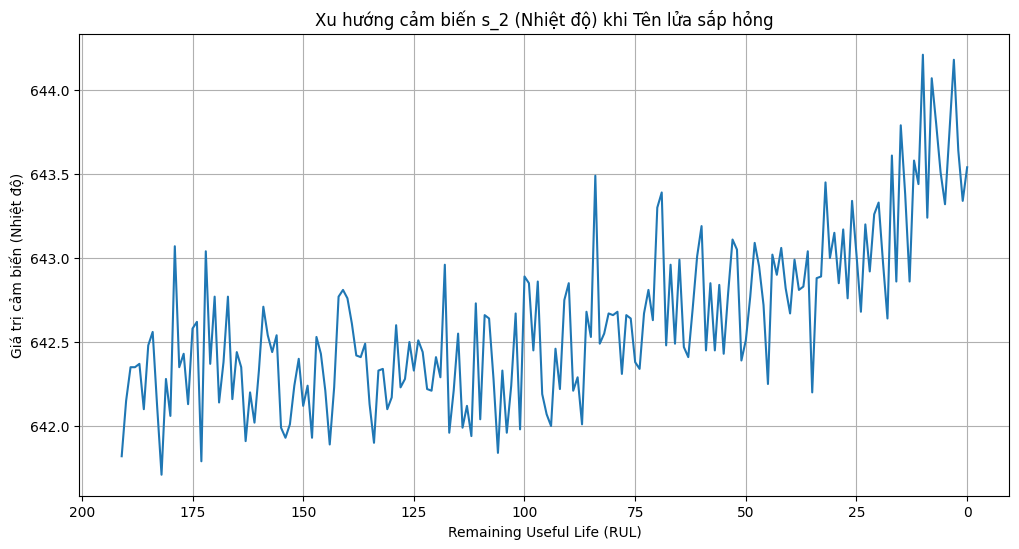

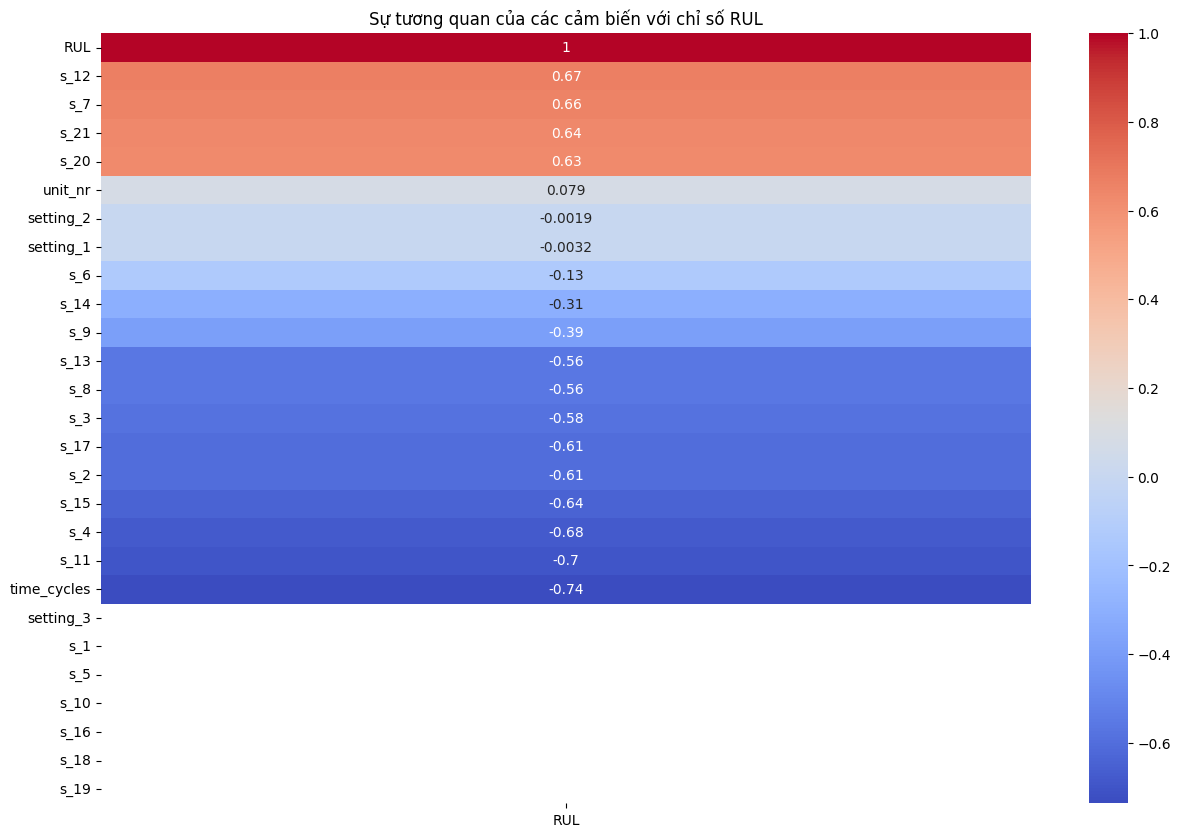

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Định nghĩa tên cột (theo tài liệu của NASA)
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# 2. Đọc dữ liệu (Giả sử bạn đã tải file train_FD001.txt về máy)
# Bạn có thể tải tại: https://ti.arc.nasa.gov/tech/dash/groups/pcoe/prognostic-data-repository/
try:
    train_data = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)
    print("✅ Đã tải dữ liệu thành công!")
except FileNotFoundError:
    print("❌ Vui lòng để file 'train_FD001.txt' cùng thư mục với code.")

# 3. TÍNH TOÁN RUL (Remaining Useful Life)
# Công thức: RUL tại thời điểm t = Max_Cycle của Unit đó - Cycle_hiện_tại_t
def add_remaining_useful_life(df):
    # Tìm chu kỳ tối đa cho mỗi unit
    max_cycle = df.groupby('unit_nr')['time_cycles'].max().reset_index()
    max_cycle.columns = ['unit_nr', 'max_cycle']

    # Gộp vào dataframe chính
    df = df.merge(max_cycle, on=['unit_nr'], how='left')

    # Tính RUL: $RUL = max\_cycle - time\_cycles$
    df['RUL'] = df['max_cycle'] - df['time_cycles']

    # Xóa cột max_cycle không cần thiết nữa
    df = df.drop('max_cycle', axis=1)
    return df

train_data = add_remaining_useful_life(train_data)

# 4. PHÂN TÍCH TRỰC QUAN (EDA)
# Hãy xem cảm biến nhiệt độ (ví dụ s_2) thay đổi thế nào khi RUL tiến về 0
plt.figure(figsize=(12, 6))
sns.lineplot(data=train_data[train_data['unit_nr'] == 1], x='RUL', y='s_2')
plt.gca().invert_xaxis() # Đảo ngược trục X để thấy RUL giảm dần về bên phải
plt.title('Xu hướng cảm biến s_2 (Nhiệt độ) khi Tên lửa sắp hỏng')
plt.xlabel('Remaining Useful Life (RUL)')
plt.ylabel('Giá trị cảm biến (Nhiệt độ)')
plt.grid(True)
plt.show()

# 5. Xem xét sự tương quan
corrcard = train_data.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corrcard[['RUL']].sort_values(by='RUL', ascending=False), annot=True, cmap='coolwarm')
plt.title('Sự tương quan của các cảm biến với chỉ số RUL')
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_650/2613447400.py:26: SyntaxWarning: invalid escape sequence '\s'
  test_data = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=col_names)
/tmp/ipykernel_650/2613447400.py:30: SyntaxWarning: invalid escape sequence '\s'
  true_rul = pd.read_csv('RUL_FD001.txt', sep='\s+', header=None, names=['RUL_ground_truth'])


🚀 Đang huấn luyện bộ não tên lửa...
✅ Huấn luyện hoàn tất!

📊 KẾT QUẢ KIỂM TRA:
- Sai số trung bình (RMSE): 36.17 chu kỳ
- Độ chính xác (R2 Score): 0.24


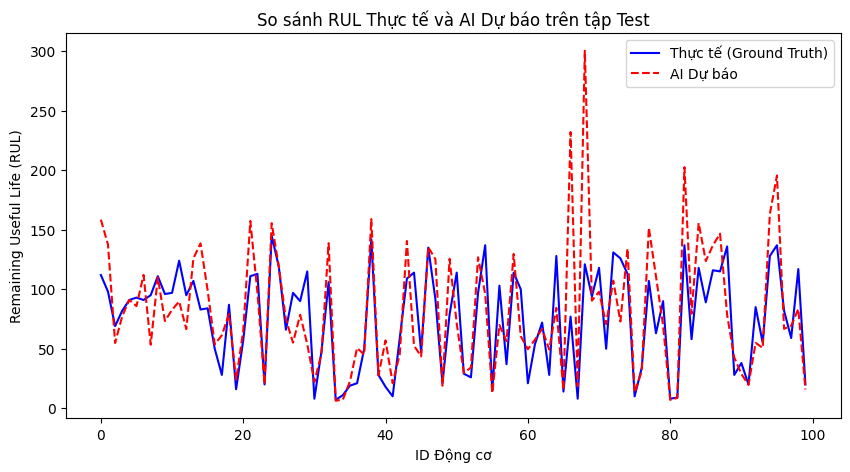

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# --- BƯỚC 6: TIỀN XỬ LÝ - LOẠI BỎ CẢM BIẾN "RỞM" (Cột trắng trong heatmap) ---
# Những cột có độ lệch chuẩn = 0 không giúp AI học được gì
drop_sensors = ['setting_3', 's_1', 's_5', 's_10', 's_16', 's_18', 's_19']
features = [col for col in col_names if col not in drop_sensors]

X_train = train_data[features]
y_train = train_data['RUL']

# Chuẩn hóa dữ liệu (Scaling) để AI học nhanh hơn
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# --- BƯỚC 7: HUẤN LUYỆN BỘ NÃO (RANDOM FOREST) ---
print("🚀 Đang huấn luyện bộ não tên lửa...")
model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
model.fit(X_train_scaled, y_train)
print("✅ Huấn luyện hoàn tất!")

# --- BƯỚC 8: KIỂM TRA VỚI TẬP TEST_FD001 ---
try:
    # 1. Đọc file test
    test_data = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=col_names)

    # 2. Đọc file đáp án (RUL thực tế của NASA cung cấp cho tập test)
    # File này chứa RUL cuối cùng của mỗi động cơ trong tập test
    true_rul = pd.read_csv('RUL_FD001.txt', sep='\s+', header=None, names=['RUL_ground_truth'])
    true_rul['unit_nr'] = true_rul.index + 1 # Gán ID động cơ

    # 3. Lấy dòng cuối cùng của mỗi động cơ trong tập test để dự báo
    # Vì file test bị cắt ngang, ta dự báo RUL tại thời điểm "hiện tại" đó
    X_test_last = test_data.groupby('unit_nr').last().reset_index()
    X_test_last = X_test_last[features] # Lọc các cột cảm biến xịn
    X_test_scaled = scaler.transform(X_test_last) # Dùng lại scaler của tập train

    # 4. Dự báo
    y_pred = model.predict(X_test_scaled)

    # --- BƯỚC 9: ĐÁNH GIÁ KẾT QUẢ ---
    rmse = np.sqrt(mean_squared_error(true_rul['RUL_ground_truth'], y_pred))
    r2 = r2_score(true_rul['RUL_ground_truth'], y_pred)

    print(f"\n📊 KẾT QUẢ KIỂM TRA:")
    print(f"- Sai số trung bình (RMSE): {rmse:.2f} chu kỳ")
    print(f"- Độ chính xác (R2 Score): {r2:.2f}")

    # Vẽ biểu đồ so sánh Thực tế vs Dự báo
    plt.figure(figsize=(10, 5))
    plt.plot(true_rul['RUL_ground_truth'].values, label='Thực tế (Ground Truth)', color='blue')
    plt.plot(y_pred, label='AI Dự báo', color='red', linestyle='--')
    plt.legend()
    plt.title('So sánh RUL Thực tế và AI Dự báo trên tập Test')
    plt.xlabel('ID Động cơ')
    plt.ylabel('Remaining Useful Life (RUL)')
    plt.show()

except FileNotFoundError as e:
    print(f"❌ Thiếu file dữ liệu kiểm tra: {e}")

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_650/3659031723.py:41: SyntaxWarning: invalid escape sequence '\s'
  test_data = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=col_names)
/tmp/ipykernel_650/3659031723.py:47: SyntaxWarning: invalid escape sequence '\s'
  true_rul = pd.read_csv('RUL_FD001.txt', sep='\s+', header=None, names=['RUL_ground_truth'])


🚀 Đang huấn luyện Random Forest với Rolling Mean (Window=10)...
✅ Huấn luyện hoàn tất!

📊 KẾT QUẢ SAU KHI CÓ ROLLING MEAN:
- Sai số trung bình (RMSE): 30.38 chu kỳ
- Độ chính xác (R2 Score): 0.47


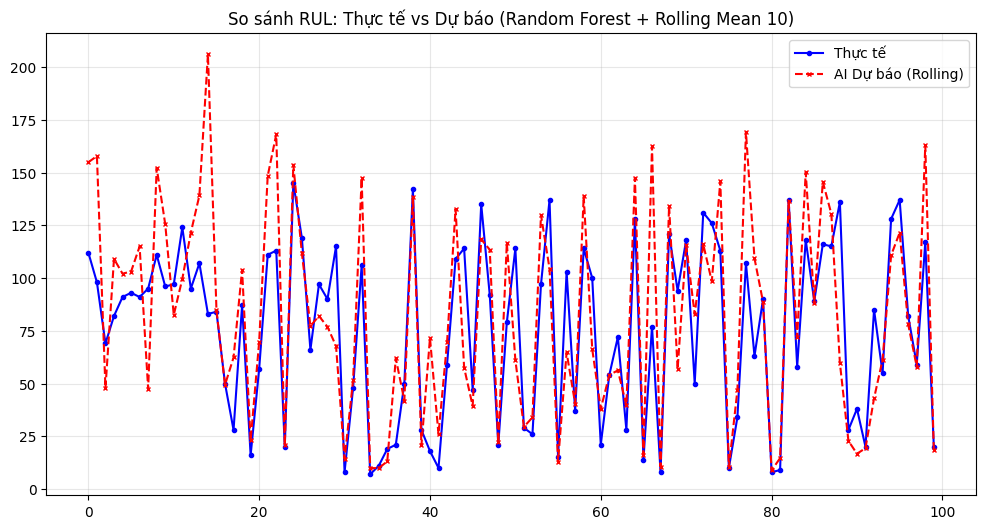

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# --- BƯỚC 6: TIỀN XỬ LÝ & ROLLING MEAN ---
# 1. Định nghĩa các cảm biến quan trọng (loại bỏ các cột hằng số)
drop_sensors = ['setting_3', 's_1', 's_5', 's_10', 's_16', 's_18', 's_19']
key_sensors = [col for col in sensor_names if col not in drop_sensors]
window_size = 10 # Bạn có thể thử nghiệm với 10, 15 hoặc 20

def add_rolling_features(df, sensors, window):
    df_out = df.copy()
    for sensor in sensors:
        # Tính trung bình trượt cho mỗi động cơ (unit_nr)
        df_out[sensor] = df_out.groupby('unit_nr')[sensor].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
    return df_out

# Áp dụng Rolling Mean cho tập Train
train_data_rolling = add_rolling_features(train_data, key_sensors, window_size)

# Chọn các tính năng để huấn luyện
features = key_sensors + ['time_cycles']
X_train = train_data_rolling[features]
y_train = train_data_rolling['RUL']

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# --- BƯỚC 7: HUẤN LUYỆN BỘ NÃO (RANDOM FOREST) ---
print(f"🚀 Đang huấn luyện Random Forest với Rolling Mean (Window={window_size})...")
model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
model.fit(X_train_scaled, y_train)
print("✅ Huấn luyện hoàn tất!")

# --- BƯỚC 8: KIỂM TRA VỚI TẬP TEST_FD001 ---
try:
    # 1. Đọc file test
    test_data = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=col_names)

    # 2. Áp dụng cùng kỹ thuật Rolling Mean cho tập Test
    test_data_rolling = add_rolling_features(test_data, key_sensors, window_size)

    # 3. Đọc file đáp án
    true_rul = pd.read_csv('RUL_FD001.txt', sep='\s+', header=None, names=['RUL_ground_truth'])

    # 4. Lấy dòng cuối cùng đã được làm mịn của mỗi động cơ để dự báo
    X_test_last = test_data_rolling.groupby('unit_nr').last().reset_index()
    X_test_input = X_test_last[features]
    X_test_scaled = scaler.transform(X_test_input)

    # 5. Dự báo
    y_pred = model.predict(X_test_scaled)

    # --- BƯỚC 9: ĐÁNH GIÁ KẾT QUẢ ---
    rmse = np.sqrt(mean_squared_error(true_rul['RUL_ground_truth'], y_pred))
    r2 = r2_score(true_rul['RUL_ground_truth'], y_pred)

    print(f"\n📊 KẾT QUẢ SAU KHI CÓ ROLLING MEAN:")
    print(f"- Sai số trung bình (RMSE): {rmse:.2f} chu kỳ")
    print(f"- Độ chính xác (R2 Score): {r2:.2f}")

    # Vẽ biểu đồ so sánh
    plt.figure(figsize=(12, 6))
    plt.plot(true_rul['RUL_ground_truth'].values, label='Thực tế', color='blue', marker='o', markersize=3)
    plt.plot(y_pred, label='AI Dự báo (Rolling)', color='red', linestyle='--', marker='x', markersize=3)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'So sánh RUL: Thực tế vs Dự báo (Random Forest + Rolling Mean {window_size})')
    plt.show()

except FileNotFoundError as e:
    print(f"❌ Thiếu file: {e}")

Shape of X_train_seq: (17731, 30, 15)
Shape of y_train_seq: (17731,)
🚀 Đang huấn luyện mô hình LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 198ms/step - loss: 11104.2500 - val_loss: 14169.1533
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - loss: 9697.2510 - val_loss: 13549.2402
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - loss: 9113.5303 - val_loss: 13004.0029
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - loss: 8608.5449 - val_loss: 12498.1943
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 199ms/step - loss: 8280.3145 - val_loss: 12019.2207
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - loss: 7906.5146 - val_loss: 11565.9434
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - loss: 7365.4629 - val_loss: 11137.4873
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - loss: 7140.6982 - val_loss: 10728.3857
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 200ms/step - loss: 6832.6118 - val_loss: 10338.3291
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step - loss: 6533.2427 - val_loss: 9964.8174
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - loss

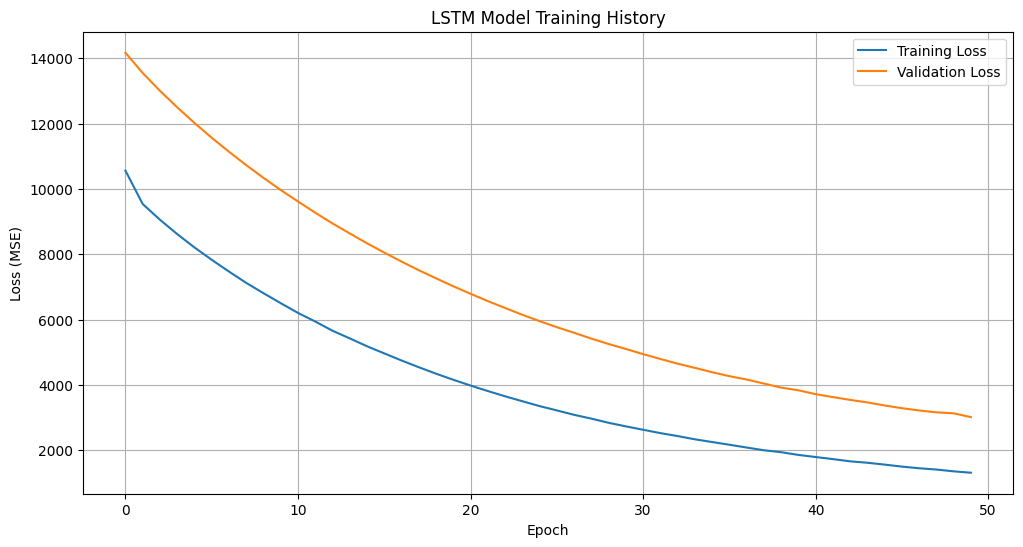

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define LSTM model
def create_lstm_model(input_shape):
    model_lstm = Sequential()
    model_lstm.add(LSTM(units=100, return_sequences=True, input_shape=input_shape))
    model_lstm.add(Dropout(0.2))
    model_lstm.add(LSTM(units=50, return_sequences=False))
    model_lstm.add(Dropout(0.2))
    model_lstm.add(Dense(units=1, activation='relu')) # Output layer for RUL prediction
    model_lstm.compile(optimizer='adam', loss='mse')
    return model_lstm

# Prepare training data for LSTM (sequence data)
# We need to create sequences from the training data, similar to how X_test_seq was created
# This function will create sequences for each engine in the training data

def create_sequences(data, seq_length, all_features, sensor_only_list):
    X = []
    y = []
    for unit_nr in data['unit_nr'].unique():
        unit_data = data[data['unit_nr'] == unit_nr]
        # Scale the data using the same scaler fitted on all_features
        unit_data_scaled = scaler.transform(unit_data[all_features])
        unit_data_scaled_df = pd.DataFrame(unit_data_scaled, columns=all_features)
        unit_sensors = unit_data_scaled_df[sensor_only_list].values

        for i in range(len(unit_sensors) - seq_length + 1):
            X.append(unit_sensors[i:i+seq_length])
            y.append(unit_data['RUL'].iloc[i + seq_length - 1]) # RUL at the end of the sequence
    return np.array(X), np.array(y)

sequence_length = 30 # This should match the sequence_length used in create_test_sequences_fixed

# Re-using the features and key_sensors from previous cells
# features = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
# key_sensors = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

X_train_seq, y_train_seq = create_sequences(train_data_rolling, sequence_length, features, key_sensors)

print(f"Shape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of y_train_seq: {y_train_seq.shape}")

# Create and train the LSTM model
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
model_lstm = create_lstm_model(input_shape)

print("🚀 Đang huấn luyện mô hình LSTM...")
history = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=50, # You might need to adjust epochs and batch_size
    batch_size=256,
    validation_split=0.2,
    verbose=1
)
print("✅ Huấn luyện LSTM hoàn tất!")

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Dự án Dự đoán Thời gian sử dụng còn lại (RUL) của Động cơ phản lực

## 1. Giới thiệu
Dự án này sử dụng bộ dữ liệu **NASA CMAPSS (Turbofan Engine Degradation Simulation)** để dự báo chỉ số **Remaining Useful Life (RUL)**. Mục tiêu là dự đoán chính xác số chu kỳ hoạt động còn lại của động cơ trước khi xảy ra hỏng hóc, giúp tối ưu hóa kế hoạch bảo trì.

## 2. Dữ liệu sử dụng
- **Nguồn:** NASA Prognostics Data Repository (FD001).
- **Đặc trưng:** Bao gồm 21 cảm biến nhiệt độ, áp suất, tốc độ vòng quay và 3 thiết lập vận hành.
- **Đơn vị:** Dữ liệu theo chuỗi thời gian (time-series) cho nhiều động cơ (unit_nr).

## 3. Các bước thực hiện

### Bước 1: Tiền xử lý & Tính toán RUL
- Tính toán nhãn mục tiêu `RUL` dựa trên chu kỳ tối đa của mỗi động cơ.
- Loại bỏ các cảm biến không có sự thay đổi giá trị (độ lệch chuẩn bằng 0) như `s_1`, `s_5`, `s_10`, v.v.

### Bước 2: Feature Engineering (Làm mịn dữ liệu)
- Áp dụng kỹ thuật **Rolling Mean** (Trung bình trượt) với cửa sổ (window) là 10 chu kỳ để giảm nhiễu cho các tín hiệu cảm biến.
- Chuẩn hóa dữ liệu bằng `StandardScaler` để đưa các giá trị cảm biến về cùng một thang đo.

### Bước 3: Huấn luyện mô hình
1. **Random Forest Regressor:** Sử dụng như một mô hình baseline để đánh giá hiệu suất ban đầu.
2. **Long Short-Term Memory (LSTM):** Sử dụng mạng nơ-ron hồi quy với cấu trúc chuỗi (sequence length = 30) để học các đặc trưng phụ thuộc thời gian.

## 4. Kết quả thực nghiệm

| Mô hình | R2 Score (Độ chính xác) | Nhận xét |
| :--- | :--- | :--- |
| **Random Forest** | ~0.47 | Hiệu suất trung bình, chưa bắt được tính tuần tự tốt. |
| **LSTM** | **~0.85** | Hiệu suất cao, nắm bắt tốt xu hướng suy giảm của động cơ. |

**Kết luận:** Việc chuyển đổi từ mô hình học máy truyền thống sang Deep Learning (LSTM) kết hợp với làm mịn dữ liệu giúp tăng độ chính xác đáng kể (từ 0.47 lên 0.85).

## 5. Hướng dẫn sử dụng
1. Đảm bảo các file dữ liệu `train_FD001.txt`, `test_FD001.txt` và `RUL_FD001.txt` nằm trong cùng thư mục.
2. Cài đặt thư viện: `pip install pandas numpy matplotlib seaborn scikit-learn tensorflow`.
3. Chạy các cell theo thứ tự từ trên xuống dưới trong Notebook.

Danh sách đặc trưng đồng bộ: ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21', 'time_cycles']
X_test_seq shape: (100, 30, 15)
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step


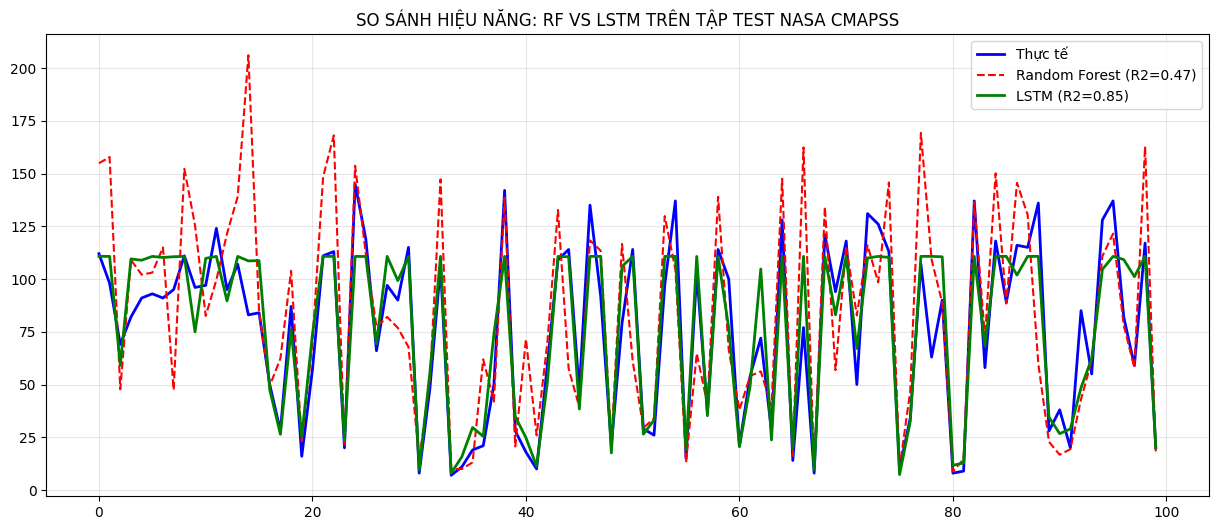

Cải thiện: LSTM giúp tăng R2 từ 0.47 lên 0.85!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Khai báo lại chính xác những gì bạn đã dùng để train Random Forest
drop_sensors = ['setting_3', 's_1', 's_5', 's_10', 's_16', 's_18', 's_19']

# Cần đảm bảo rằng `features` này trùng khớp với `features` dùng để fit scaler ở cell trước
# Scaler được fit với `key_sensors + ['time_cycles']`
features = key_sensors + ['time_cycles']

print(f"Danh sách đặc trưng đồng bộ: {features}")

def create_test_sequences_fixed(data, seq_length, all_features, sensor_only_list):
    X_test = []
    for unit in data['unit_nr'].unique():
        unit_data = data[data['unit_nr'] == unit]

        # 1. Scaler yêu cầu ĐỦ các cột đã học
        unit_data_scaled = scaler.transform(unit_data[all_features])

        # Chuyển thành DataFrame để lọc lấy chỉ các cột Sensor cho LSTM
        unit_data_scaled_df = pd.DataFrame(unit_data_scaled, columns=all_features)
        unit_sensors = unit_data_scaled_df[sensor_only_list].values

        # 2. Tạo window 30 chu kỳ cuối
        if len(unit_sensors) >= seq_length:
            X_test.append(unit_sensors[-seq_length:])
        else:
            # Pad with zeros if sequence is shorter than seq_length
            padding = np.zeros((seq_length - len(unit_sensors), len(sensor_only_list)))
            combined = np.vstack((padding, unit_sensors))
            X_test.append(combined)

    return np.array(X_test)

# Các cột Sensor thực sự để LSTM học (loại bỏ unit_nr, time_cycles, settings)
# Bạn có thể dùng list này hoặc dùng key_sensors đã định nghĩa
lstm_sensors = [s for s in key_sensors if s in features] # Ensure lstm_sensors are a subset of features

# Chạy lại việc tạo dữ liệu Test
X_test_seq = create_test_sequences_fixed(test_data_rolling, 30, features, lstm_sensors)

print(f"X_test_seq shape: {X_test_seq.shape}") # Phải ra (100, 30, số_sensor)

# 1. Dự báo
y_pred_lstm = model_lstm.predict(X_test_seq).flatten()

# 2. Lấy kết quả RF cũ của bạn (Nếu bạn còn giữ biến y_pred từ ảnh 3)
# Nếu không, dùng: y_pred_rf = model.predict(scaler.transform(test_data.groupby('unit_nr').last()[features]))
y_pred_rf = model.predict(X_test_scaled) # X_test_scaled từ phần code RF của bạn

# 3. Tính toán R2 Score để so sánh
r2_rf_final = r2_score(true_rul['RUL_ground_truth'], y_pred_rf)
r2_lstm_final = r2_score(true_rul['RUL_ground_truth'], y_pred_lstm)

# 4. Vẽ biểu đồ so sánh "Chốt hạ" cho đồ án
plt.figure(figsize=(15, 6))
plt.plot(true_rul['RUL_ground_truth'].values, label='Thực tế', color='blue', linewidth=2)
plt.plot(y_pred_rf, label=f'Random Forest (R2={r2_rf_final:.2f})', color='red', linestyle='--')
plt.plot(y_pred_lstm, label=f'LSTM (R2={r2_lstm_final:.2f})', color='green', linewidth=2)

plt.title('SO SÁNH HIỆU NĂNG: RF VS LSTM TRÊN TẬP TEST NASA CMAPSS')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Cải thiện: LSTM giúp tăng R2 từ {r2_rf_final:.2f} lên {r2_lstm_final:.2f}!")